In [85]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras

In [86]:
import torch
torch.cuda.is_available()

True

In [87]:
from keras.models import Sequential, Model
from keras.layers import Dense, Input, ReLU, Flatten
from keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
from keras.metrics import Accuracy
from keras.optimizers import Adam

from keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [88]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape) 
print(y_train.shape)
print(x_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)


In [89]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=1)
print(f'{x_train.shape} - {x_val.shape}')

(48000, 28, 28) - (12000, 28, 28)


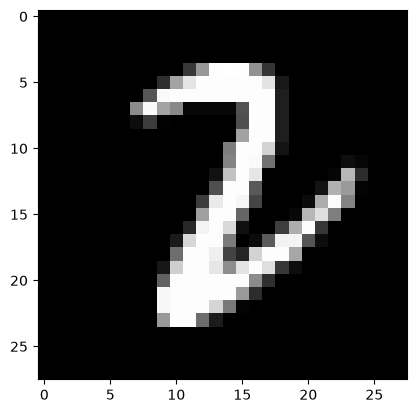

In [90]:
plt.imshow(x_train[21485], cmap='gray')
plt.show()

In [91]:
def build_model(activation: str ='relu'):
    model = Sequential([
        Input(shape=( 28, 28))
        , Flatten()
        , Dense(units=64, activation=activation)
        , Dense(units=64, activation=activation)
        , Dense(units=128, activation=activation)
        , Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam()
        , loss=SparseCategoricalCrossentropy()
        , metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,010 (250.04 KB)

 Trainable params: 64,010 (250.04 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
model.fit(x_train, y_train, batch_size=512, epochs=50, validation_data=(x_val, y_val))

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7132 - loss: 3.9984 - val_accuracy: 0.8236 - val_loss: 2.3808
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8801 - loss: 1.3660 - val_accuracy: 0.9154 - val_loss: 0.7896
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9261 - loss: 0.6480 - val_accuracy: 0.9258 - val_loss: 0.5993
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9419 - loss: 0.4313 - val_accuracy: 0.9308 - val_loss: 0.5124
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9517 - loss: 0.3289 - val_accuracy: 0.9310 - val_loss: 0.4728
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9578 - loss: 0.2567 - val_accuracy: 0.9389 - val_loss: 0.3870
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9628 - loss: 0.2067 - val_accuracy: 0.9426 - val_loss: 0.3679
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9672 - loss: 0.1728 - val_accuracy: 0.9428 - val_loss

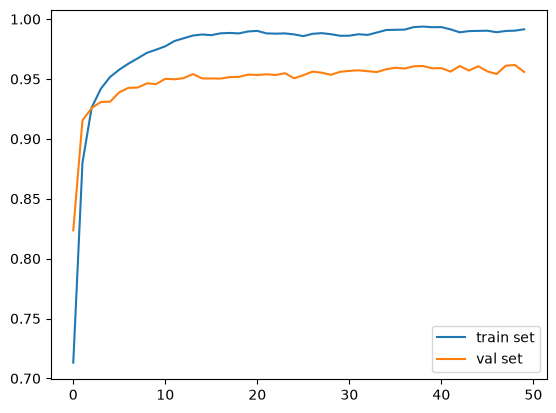

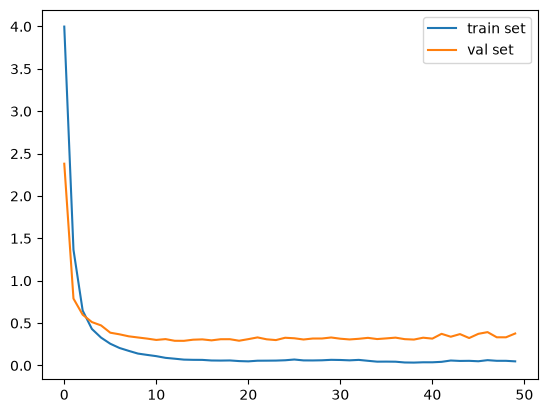

In [93]:
logs = model.history.history

plt.Figure(figsize=(7, 5))
plt.plot(logs['accuracy'], label='train set')
plt.plot(logs['val_accuracy'], label='val set')
plt.legend()
plt.show()

plt.Figure(figsize=(7, 5))
plt.plot(logs['loss'], label='train set')
plt.plot(logs['val_loss'], label='val set')
plt.legend()
plt.show()

In [18]:
y_pred_proba = model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_pred

  1/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [24]:
#accuracterminal: openy
(y_pred == y_test).sum()/y_test.shape[0]

np.float64(0.9638)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.96      0.97      0.96       982
           5       0.94      0.96      0.95       892
           6       0.97      0.96      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



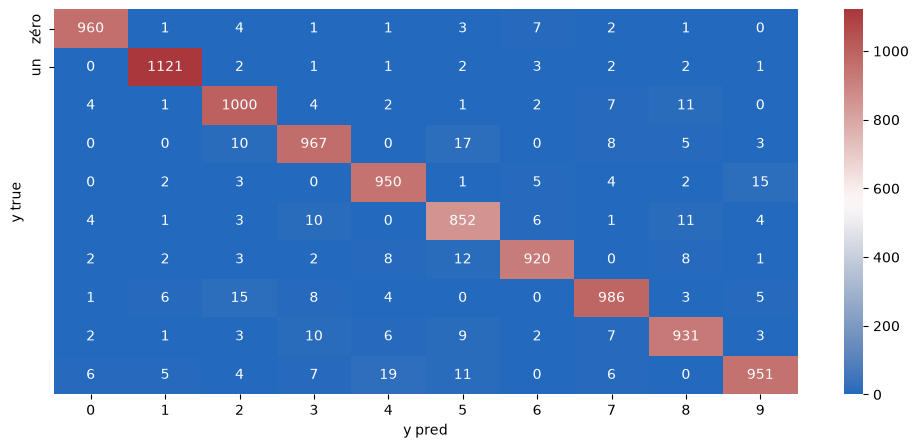

In [44]:
crosstab = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 5))
sns.heatmap(crosstab, cmap='vlag', annot=True, fmt='d', yticklabels=['zéro', 'un'])
plt.xlabel('y pred')
plt.ylabel('y true')
plt.show()